In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("data/healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [7]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [ ]:
df = df.dropna()

In [9]:
df = df.drop_duplicates()

In [10]:
df['Gender'] = df['Gender'].str.strip().str.capitalize()

In [11]:
bins = [0, 18, 35, 50, 65, 100]
labels = ['Child', 'Young Adult', 'Adult', 'Senior', 'Elderly']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [13]:
disease_count = df['Medical Condition'].value_counts()
disease_count.head()

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Name: count, dtype: int64

In [ ]:
disease_count = df['Medical Condition'].value_counts()

age_disease = df.groupby('Age_Group')['Medical Condition'].count()

gender_disease = df.groupby('Gender')['Medical Condition'].count()

risk = df.groupby(['Age_Group', 'Gender'])['Medical Condition'].count()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22956\2388499168.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_disease = df.groupby('Age_Group')['Medical Condition'].count()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22956\2388499168.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df.groupby(['Age_Group', 'Gender'])['Medical Condition'].count()


In [15]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Age_Group'],
      dtype='object')

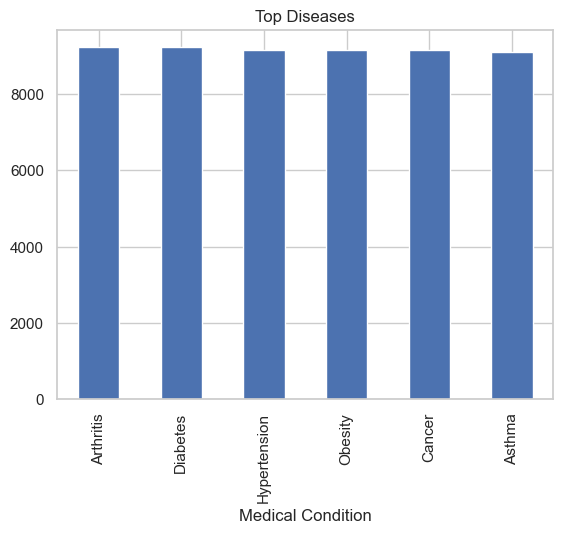

In [16]:
disease_count.head(10).plot(kind='bar')
plt.title("Top Diseases")
plt.show()

In [18]:
age_disease = df.groupby('Age_Group')['Medical Condition'].count()
age_disease

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22956\374619849.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_disease = df.groupby('Age_Group')['Medical Condition'].count()


Age_Group
Child            886
Young Adult    13519
Adult          12167
Senior         12298
Elderly        16096
Name: Medical Condition, dtype: int64

In [19]:
gender_disease = df.groupby('Gender')['Medical Condition'].count()
gender_disease

Gender
Female    27470
Male      27496
Name: Medical Condition, dtype: int64

In [20]:
risk = df.groupby(['Age_Group', 'Gender'])['Medical Condition'].count().sort_values(ascending=False)
risk.head(10)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22956\4277465123.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df.groupby(['Age_Group', 'Gender'])['Medical Condition'].count().sort_values(ascending=False)


Age_Group    Gender
Elderly      Female    8111
             Male      7985
Young Adult  Female    6778
             Male      6741
Senior       Male      6224
Adult        Male      6113
Senior       Female    6074
Adult        Female    6054
Child        Female     453
             Male       433
Name: Medical Condition, dtype: int64

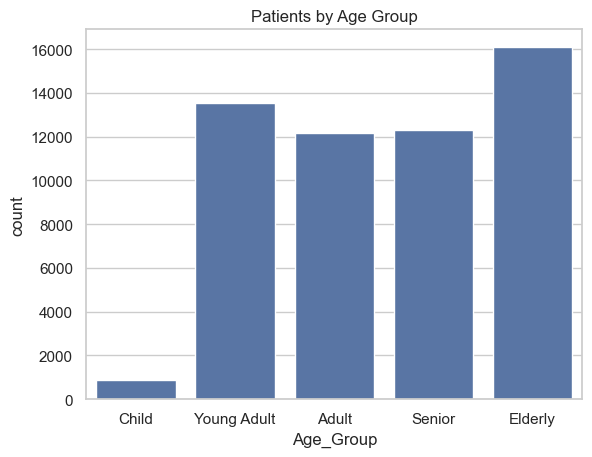

In [21]:
sns.countplot(x='Age_Group', data=df)
plt.title("Patients by Age Group")
plt.show()

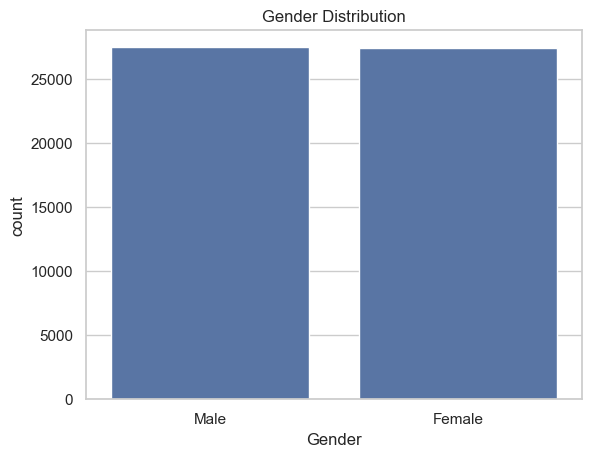

In [22]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22956\3739608496.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index='Age_Group', columns='Gender', values='Medical Condition', aggfunc='count')


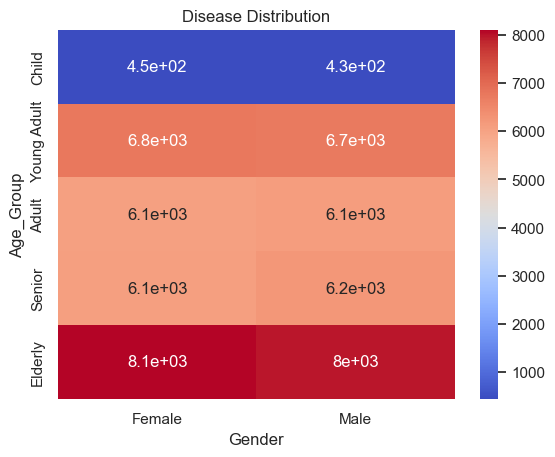

In [23]:
pivot = df.pivot_table(index='Age_Group', columns='Gender', values='Medical Condition', aggfunc='count')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Disease Distribution")
plt.show()

In [24]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results', 'Age_Group'],
      dtype='object')

In [25]:
disease_count.head()
age_disease
gender_disease
risk.head()

Age_Group    Gender
Elderly      Female    8111
             Male      7985
Young Adult  Female    6778
             Male      6741
Senior       Male      6224
Name: Medical Condition, dtype: int64